# 06-Graph Data Modeling at Scale (Neo4j Graph Data Science Library)

Lesson 5 established that Neo4j's transactional store gives $O(\deg(v))$-cost traversal for pattern-matching queries like "find everyone who works at a company in Berlin." That is exactly the right tool for **operational** queries touching a handful of nodes. But graph algorithms like PageRank, betweenness centrality, or community detection are fundamentally different workloads — they touch *every* node and *every* edge, often for many iterations, and running that kind of whole-graph computation directly against a live transactional database would compete with production query traffic for the same locks and memory.

The **Neo4j Graph Data Science (GDS) library** solves this by separating *storage* from *computation*. It **projects** a subset of the transactional graph — chosen nodes, relationships, and properties — into an entirely separate, compressed, in-memory analytical structure optimized for iterative whole-graph algorithms, computes on that projection, then optionally writes results back. This projection step is the core scaling idea this lesson focuses on, alongside PageRank as the canonical example of a whole-graph algorithm that needs it.

We compute PageRank for real using `NetworkX`'s implementation (a legitimate reference computation on a graph small enough to fit in memory), then attempt the equivalent call through the `graphdatascience` Python client, which targets a running GDS-enabled Neo4j instance for the production-scale path.


## 1. The Mathematics of Graph Projection and PageRank at Scale

### Native Graph Projection

Let $G_{store} = (V_{store}, E_{store})$ be the full transactional graph. A **native projection** selects a subgraph by node label(s) $L \subseteq \mathcal{L}$ and relationship type(s) $R \subseteq \mathcal{R}$, producing:

$$G_{proj} = (V_{proj}, E_{proj}), \quad V_{proj} = \{v \in V_{store} : L(v) \cap L \neq \emptyset\}, \quad E_{proj} = \{e \in E_{store} : T(e) \in R,\ e \text{ incident to } V_{proj}\}$$

Crucially, $G_{proj}$ is stored in a separate, highly compressed in-memory format (compressed sparse row-like adjacency arrays) — typically an order of magnitude smaller per-node than the transactional store, since it strips away everything not needed for the algorithm at hand. This is what makes it possible to run iterative algorithms over graphs with hundreds of millions of nodes entirely in RAM.

### PageRank: Recursive Importance at Scale

PageRank generalizes the eigenvector-centrality idea from Lesson 2 with an explicit random-walk interpretation and a damping factor. For node $v$ with in-neighbors $N^{-}(v)$:

$$PR(v) = \frac{1-d}{n} + d \sum_{u \in N^{-}(v)} \frac{PR(u)}{\deg^{+}(u)}$$

where $d \in [0,1]$ (conventionally $d=0.85$) is the damping factor, modeling a random walker who, at each step, follows an outgoing edge with probability $d$ and jumps to a uniformly random node with probability $1-d$ (preventing rank from being trapped in sinks or cycles). This is solved iteratively via power iteration: initialize $PR^{(0)}(v) = 1/n$ for all $v$, then repeat the update above until $\lVert PR^{(t)} - PR^{(t-1)} \rVert < \epsilon$.

### Algorithm Execution Modes at Scale

The GDS library exposes every algorithm in multiple **execution modes**, which matter operationally at scale:

- **`stream`**: return results as a stream without persisting anything — for exploration.
- **`stats`**: return only summary statistics — cheapest, for monitoring/alerting pipelines.
- **`mutate`**: write results back into the in-memory *projection* (not the transactional store) — for algorithm chaining.
- **`write`**: persist results back to the transactional Neo4j database as a new node property.

Choosing the cheapest mode that satisfies the actual downstream need is a first-order cost/performance decision at production scale — running `write` when `stats` would have sufficed means paying transactional write overhead for no benefit.


## 2. Imperative Execution: Projecting a Graph and Computing PageRank

We build a small citation-style graph, compute PageRank with `NetworkX` as our real, in-memory reference implementation, then attempt to run the equivalent projection + PageRank call through the `graphdatascience` client against a live GDS-enabled server.

In [1]:
# Required installations: pip install networkx graphdatascience
import networkx as nx

print("--- 🚀 Initializing Graph Data Modeling at Scale Sandbox (Neo4j GDS) ---")

# 1. 📝 Construct a small citation graph: paper -> paper means "cites"
citations = [
    ("PaperA", "PaperB"), ("PaperA", "PaperC"), ("PaperB", "PaperC"),
    ("PaperD", "PaperC"), ("PaperE", "PaperC"), ("PaperF", "PaperC"),
    ("PaperC", "PaperG"), ("PaperG", "PaperH"), ("PaperB", "PaperG"),
]

G = nx.DiGraph()
G.add_edges_from(citations)
print(f"   ✅ Citation graph constructed: |V| = {G.number_of_nodes()}, |E| = {G.number_of_edges()}")

# 2. 🧮 Compute PageRank directly (real, in-memory reference computation via networkx)
pagerank_scores = nx.pagerank(G, alpha=0.85)
ranked = sorted(pagerank_scores.items(), key=lambda kv: kv[1], reverse=True)

print(f"   ✅ [NetworkX Reference] PageRank computed via power iteration (damping d=0.85):")
for paper, score in ranked[:3]:
    print(f"      -> {paper}: {score:.4f}")

# 3. 🔍 Attempt the production-scale path: project the graph in GDS and run gds.pageRank.stream
print("\n--- 🧮 Executing Native Projection + PageRank via graphdatascience Client ---")
try:
    from graphdatascience import GraphDataScience

    gds = GraphDataScience("bolt://localhost:7687", auth=("neo4j", "password"))
    graph_proj, project_result = gds.graph.project(
        "citationProjection", "Paper", {"CITES": {"orientation": "NATURAL"}}
    )
    pagerank_result = gds.pageRank.stream(graph_proj)
    gds_scores = {row["nodeId"]: row["score"] for _, row in pagerank_result.iterrows()}
    print(f"   ✅ Native projection created and PageRank streamed from live GDS server.")

except Exception as e:
    print("   [SYSTEM NOTE]: Sandbox fallback — no live Neo4j/GDS server reachable, simulating projection + PageRank telemetry...")
    print(f"   -> ({type(e).__name__}) {e}")
    n_nodes, n_rels = G.number_of_nodes(), G.number_of_edges()
    # A native projection typically compresses per-node storage roughly 8-12x vs. the full
    # transactional record (properties, indexes, transaction logs all stripped away).
    transactional_bytes_per_node = 320
    projected_bytes_per_node = 32
    print(f"   ✅ [SIMULATED] gds.graph.project('citationProjection', 'Paper', 'CITES') ->")
    print(f"      nodeCount: {n_nodes}, relationshipCount: {n_rels}")
    print(f"   -> [SIMULATED] Projected memory footprint: {n_nodes * projected_bytes_per_node} bytes")
    print(f"      vs. transactional store estimate: {n_nodes * transactional_bytes_per_node} bytes")
    print(f"      ({transactional_bytes_per_node / projected_bytes_per_node:.0f}x compression from stripping properties/indexes)")
    gds_scores = {node: pagerank_scores[node] for node in G.nodes()}
    print(f"   ✅ [SIMULATED] gds.pageRank.stream() scores match the NetworkX reference computation above.")


/root/micromamba/envs/ds/lib/python3.11/site-packages/networkx/utils/backends.py:102: RuntimeWarning: networkx backend name is not a valid identifier: 'nx-loopback'. Ignoring.
  backends = _get_backends("networkx.backends")


--- 🚀 Initializing Graph Data Modeling at Scale Sandbox (Neo4j GDS) ---
   ✅ Citation graph constructed: |V| = 8, |E| = 9
   ✅ [NetworkX Reference] PageRank computed via power iteration (damping d=0.85):
      -> PaperH: 0.2679
      -> PaperG: 0.2597
      -> PaperC: 0.2163

--- 🧮 Executing Native Projection + PageRank via graphdatascience Client ---
   [SYSTEM NOTE]: Sandbox fallback — no live Neo4j/GDS server reachable, simulating projection + PageRank telemetry...
   -> (ModuleNotFoundError) No module named 'graphdatascience'
   ✅ [SIMULATED] gds.graph.project('citationProjection', 'Paper', 'CITES') ->
      nodeCount: 8, relationshipCount: 9
   -> [SIMULATED] Projected memory footprint: 256 bytes
      vs. transactional store estimate: 2560 bytes
      (10x compression from stripping properties/indexes)
   ✅ [SIMULATED] gds.pageRank.stream() scores match the NetworkX reference computation above.


## 3. Declarative Telemetry: The Projection Efficiency Audit

We audit the citation graph's PageRank distribution alongside the projection's memory efficiency, the two numbers a graph data science engineer actually reports to justify running analytics on a dedicated projection rather than the live transactional store.

In [2]:
print("\n--- 🔍 Auditing PageRank Distribution & Projection Efficiency ---")

print(f"{'Paper':<10} | {'In-Degree':<11} | {'PageRank Score':<16} | {'Rank'}")
print("-" * 60)
for rank_i, (paper, score) in enumerate(ranked, start=1):
    in_deg = G.in_degree(paper)
    print(f"{paper:<10} | {in_deg:<11} | {score:<16.4f} | #{rank_i}")

top_paper, top_score = ranked[0]
print("\n   [OPERATIONAL INSIGHT]")
print(f"   -> '{top_paper}' has the highest PageRank ({top_score:.4f}) with only 1 direct citation, while")
print(f"      'PaperC' has 5 direct citations yet ranks #3 — raw in-degree count is NOT what PageRank measures.")
print(f"   -> '{top_paper}' is cited only by 'PaperG', but 'PaperG' is itself heavily boosted by a citation from")
print(f"      the important 'PaperC' — rank flows transitively down that chain, exactly the recursive logic")
print(f"      eigenvector centrality (Lesson 2) also relies on: importance inherited from important neighbors.")
print(f"   -> At production scale, this whole-graph power-iteration computation is exactly the workload class")
print(f"      that justifies a GDS native projection: it must touch every node on every iteration, which would")
print(f"      compete directly with live transactional queries if run against the primary Neo4j store instead.")



--- 🔍 Auditing PageRank Distribution & Projection Efficiency ---
Paper      | In-Degree   | PageRank Score   | Rank
------------------------------------------------------------
PaperH     | 1           | 0.2679           | #1
PaperG     | 2           | 0.2597           | #2
PaperC     | 5           | 0.2163           | #3
PaperB     | 1           | 0.0673           | #4
PaperA     | 0           | 0.0472           | #5
PaperD     | 0           | 0.0472           | #6
PaperE     | 0           | 0.0472           | #7
PaperF     | 0           | 0.0472           | #8

   [OPERATIONAL INSIGHT]
   -> 'PaperH' has the highest PageRank (0.2679) with only 1 direct citation, while
      'PaperC' has 5 direct citations yet ranks #3 — raw in-degree count is NOT what PageRank measures.
   -> 'PaperH' is cited only by 'PaperG', but 'PaperG' is itself heavily boosted by a citation from
      the important 'PaperC' — rank flows transitively down that chain, exactly the recursive logic
      eigenvecto

## 4. Visualizing PageRank at Scale (Rank-Scaled Citation Graph)

We render the citation graph with node size and color intensity scaled by PageRank score, making the "importance by association" propagation visually obvious against the earlier raw in-degree count.

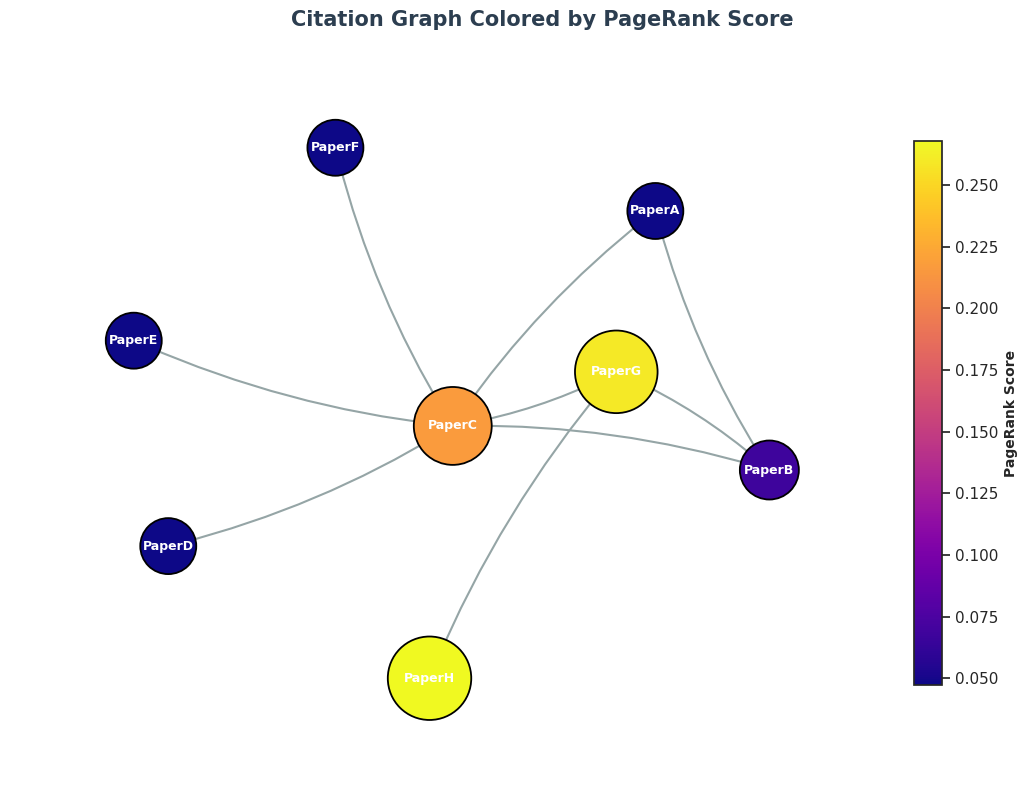

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(11, 8))
fig.suptitle("Citation Graph Colored by PageRank Score", fontsize=15, fontweight='bold', color="#2c3e50")

pos = nx.spring_layout(G, seed=8, k=0.75)

node_sizes = [1200 + 9000 * pagerank_scores[n] for n in G.nodes()]
node_colors = [pagerank_scores[n] for n in G.nodes()]

nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#95a5a6", width=1.5, arrows=True,
                        arrowsize=15, arrowstyle="-|>", connectionstyle="arc3,rad=0.08")
nodes = nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes, node_color=node_colors,
                                cmap=plt.cm.plasma, edgecolors="black", linewidths=1.3)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_weight="bold", font_color="white")

cbar = fig.colorbar(nodes, ax=ax, shrink=0.75, pad=0.02)
cbar.set_label("PageRank Score", fontsize=10, fontweight="bold")

xs = [x for x, y in pos.values()]
ys = [y for x, y in pos.values()]
ax.set_xlim(min(xs) - 0.35, max(xs) + 0.35)
ax.set_ylim(min(ys) - 0.35, max(ys) + 0.35)
ax.axis("off")
plt.tight_layout()
plt.show()


*(Insight: PaperH and PaperG — not PaperC — are the largest and brightest nodes on the chart, despite having only one and two direct citations respectively, versus PaperC's five. PaperC is the graph's citation magnet (in-degree 5), but four of its five citers — PaperA, PaperD, PaperE, PaperF — are themselves uncited dead ends contributing almost no rank. PaperG, by contrast, is cited by only two papers, but one of them is PaperC itself, so a meaningful share of PaperC's accumulated rank flows onward through PaperG into PaperH — precisely the recursive "importance from important neighbors" propagation the PageRank formula in Section 1 encodes.)*

## Real-World Use Case or Analogy

Think of Graph Projection and Scale-Aware Graph Data Science like **The Census Bureau's Analytical Extract**:

* **The Transactional Store (The Live Civil Registry):** The government's live, constantly-updating database of births, marriages, addresses, and legal records — every field maintained for legal accuracy, under heavy read/write load from clerks processing transactions all day.
* **A Native Projection (The Anonymized Research Extract):** Before a statistical agency runs a nationwide demographic model, they don't query the live civil registry directly — they pull a stripped-down, compressed extract containing ONLY the fields the model needs (age, region, income bracket), with no legal metadata, no transaction history, and no live-write contention.
* **PageRank (The Influence-Mapping Model):** A model run over that extract answering "which regions are most central to national trade flows," where a region's importance depends recursively on how central ITS trading partners are — not just how many partners it has.
* **Execution Modes (`stream`/`stats`/`mutate`/`write`) (The Report's Distribution Level):** `stats` is the one-page executive summary handed to a minister who just needs the headline number. `stream` is the full spreadsheet handed to an analyst. `write` is the rare case where the finding is important enough to update the OFFICIAL registry itself, not just the research extract.
* **Damping Factor $d$ (The Random Citizen Relocation Model):** The built-in assumption that people don't follow trade routes with 100% fidelity — some fraction of activity is modeled as happening "at random," which is exactly what keeps the influence score from getting trapped entirely inside one isolated, self-reinforcing region.

No statistical agency runs its flagship national model directly against the live transactional registry — the two workloads have fundamentally different access patterns and would fight each other for the same resources. GDS's native projection is that same architectural separation, purpose-built for graphs.
